<a href="https://colab.research.google.com/github/camilanurahma/MACHINE-LEARNING-KLASIFIKASI/blob/main/2304010030_Klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Konteks**

Dalam sektor pelayanan kesehatan, kualitas layanan rumah sakit merupakan aspek penting yang berpengaruh terhadap keselamatan dan kepuasan pasien. Salah satu indikator yang sering digunakan untuk menilai kualitas tersebut adalah tingkat rawat inap kembali (readmission) dalam jangka waktu tertentu, khususnya dalam 30 hari setelah pasien dipulangkan.

Tingginya angka readmission dapat mengindikasikan bahwa perawatan yang diberikan belum optimal, baik dari sisi diagnosis, pengobatan, maupun tindak lanjut setelah pasien keluar dari rumah sakit. Selain itu, kondisi ini juga meningkatkan beban operasional rumah sakit serta biaya perawatan kesehatan secara keseluruhan. Oleh karena itu, diperlukan pemahaman yang lebih baik terhadap faktor-faktor yang memengaruhi kemungkinan terjadinya readmission agar dapat dilakukan langkah pencegahan yang tepat.

## **Problem Statement**

Rumah sakit menghadapi kesulitan dalam mengidentifikasi pasien yang berpotensi mengalami rawat inap kembali dalam waktu 30 hari setelah keluar dari rumah sakit. Hal ini disebabkan oleh banyaknya faktor yang memengaruhi, seperti usia pasien, jumlah penyakit penyerta (komorbiditas), lama rawat inap, riwayat rawat inap sebelumnya, serta jenis perawatan yang diterima.

Dengan kompleksitas tersebut, proses identifikasi secara manual menjadi kurang efektif dan berpotensi menghasilkan keputusan yang kurang akurat. Oleh karena itu, diperlukan suatu pendekatan berbasis data dengan memanfaatkan teknik machine learning untuk membangun model klasifikasi yang mampu memprediksi apakah seorang pasien akan mengalami readmission atau tidak.

Permasalahan ini penting untuk diselesaikan karena tingginya tingkat readmission tidak hanya berdampak pada kualitas pelayanan, tetapi juga pada efisiensi penggunaan sumber daya dan biaya dalam sistem kesehatan.

## **Tujuan**

Berdasarkan permasalahan yang telah dijelaskan, penelitian ini bertujuan untuk mengembangkan model klasifikasi menggunakan metode machine learning guna memprediksi kemungkinan pasien mengalami readmission dalam waktu 30 hari setelah keluar dari rumah sakit.

Selain itu, penelitian ini juga bertujuan untuk:

- Mengidentifikasi variabel-variabel yang berpengaruh terhadap terjadinya readmission
- Membandingkan performa beberapa algoritma klasifikasi untuk menentukan model yang paling optimal
- Memberikan insight yang dapat digunakan sebagai dasar pengambilan keputusan dalam upaya pencegahan readmission

Dengan adanya model prediksi ini, diharapkan pihak rumah sakit dapat melakukan tindakan preventif secara lebih tepat sasaran, sehingga kualitas layanan dapat ditingkatkan dan tingkat readmission dapat ditekan.

# **DATA**

In [423]:
import pandas as pd

df = pd.read_csv('/content/hospital_readmission_dataset.csv')
df

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1


Data tersebut merupakan data yang menggambarkan kondisi pasien rumah sakit yang berpotensi mengalami rawat inap kembali (readmission) dalam waktu 30 hari setelah keluar dari rumah sakit. Dataset ini terdiri dari berbagai variabel klinis dan demografis pasien yang dapat digunakan untuk melakukan analisis dan pemodelan klasifikasi.

Berikut adalah variabel-variabel yang terdapat dalam dataset:

- patient_id : identitas unik setiap pasien
- admission_date : tanggal pasien masuk rumah sakit
- season : musim saat pasien dirawat (Winter, Spring, Summer, Fall)
- age : usia pasien
- gender : jenis kelamin pasien
- region : wilayah tempat tinggal pasien
- primary_diagnosis : diagnosis utama pasien
- comorbidities_count : jumlah penyakit penyerta yang dimiliki pasien
- length_of_stay : lama hari pasien dirawat di rumah sakit
- treatment_type : jenis perawatan yang diberikan (medis, bedah, dll.)
- medications_count : jumlah obat yang diresepkan
- followup_visits_last_year : jumlah kunjungan kontrol dalam 1 tahun terakhir
- prev_readmissions : jumlah riwayat rawat inap sebelumnya
- insurance_type : jenis asuransi pasien
- discharge_disposition : kondisi atau tujuan setelah pasien keluar (rumah, rehabilitasi, dll.)
- label : status readmission (0 = tidak, 1 = ya dalam 30 hari)

Dataset yang dimiliki mencakup berbagai variabel yang berkaitan dengan kondisi kesehatan pasien, riwayat perawatan, serta faktor demografis. Variabel seperti jumlah komorbiditas, lama rawat inap, serta riwayat rawat inap sebelumnya dapat memberikan gambaran mengenai tingkat keparahan kondisi pasien. Sementara itu, variabel seperti usia, jenis perawatan, dan jumlah kunjungan kontrol juga berpotensi memengaruhi risiko pasien untuk kembali dirawat.

Dengan memahami karakteristik data ini, model machine learning dapat dikembangkan untuk mengidentifikasi pasien yang memiliki risiko tinggi mengalami readmission. Hasil dari analisis ini diharapkan dapat membantu pihak rumah sakit dalam mengambil langkah preventif yang lebih tepat dan meningkatkan kualitas pelayanan kesehatan secara keseluruhan.

### **Menampilkan Informasi Lengkap Dataset**

Setelah dataset berhasil dipanggil, untuk mengetahui gambaran umum dataset digunakan df.info(). Output ini menampilkan jumlah data, nama kolom, tipe data setiap variabel, serta jumlah data yang kosong pada masing-masing kolom.

In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

Berdasarkan output informasi dataset, diketahui bahwa data terdiri dari 8000 baris dan 17 kolom. Seluruh kolom memiliki 8000 data non-null, sehingga dapat disimpulkan bahwa tidak terdapat missing value pada dataset.

Tipe data dalam dataset terdiri dari 9 kolom bertipe object (data kategorikal), 7 kolom bertipe int64 yang merupakan data numerik dan 1 kolom bertipe float yang berupa data numerik desimal.

# **STATISTIK DESKRIPTIF**

Setelah melakukan pengecekan awal terhadap struktur dan kelengkapan data, analisis statistik deskriptif dilakukan untuk melihat gambaran umum distribusi data.

In [425]:
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


Dari analisis tersebut menunjukkan bahwa rata-rata usia pasien adalah sekitar 57 tahun dengan rentang 18-95 tahun. Rata-rata jumlah komorbiditas sekitar 4 kondisi, dengan lama rawat inap sekitar 7-8 hari. Pasien rata-rata menerima sekitar 7 jenis obat dan melakukan 3–4 kali kunjungan kontrol dalam setahun terakhir. Riwayat rawat inap sebelumnya rata-rata sekitar 1–2 kali. Nilai rata-rata readmission risk score berada di sekitar 0.77, menunjukkan tingkat risiko yang relatif tinggi.

Selanjutnya, untuk melihat variasi dan karakteristik setiap variabel, ditampilkan nilai unik pada masing-masing kolom berikut ini :

In [426]:
import pandas as pd

pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', None)

summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'n_unique': [df[col].nunique() for col in df.columns],
    'unique_values': [', '.join(map(str, df[col].unique())) for col in df.columns]
})

summary

,column,dtype,n_unique,unique_values
0,patient_id,object,8000,"P00001, P00002, P00003, P00004, P00005, P00006, P00007, P00008, P00009, P00010, P00011, P00012, P00013, P00014, P00015, P00016, P00017, P00018, P00019, P00020, P00021, P00022, P00023, P00024, P000..."
1,admission_date,object,1092,"2022-04-14, 2021-09-19, 2023-04-12, 2023-08-14, 2021-11-05, 2021-04-15, 2021-10-05, 2021-04-24, 2021-12-20, 2022-08-13, 2023-12-03, 2022-03-14, 2021-08-29, 2021-07-02, 2021-07-09, 2021-07-30, 2023..."
2,season,object,4,"Spring, Fall, Summer, Winter"
3,age,int64,78,"66, 55, 69, 83, 54, 84, 71, 50, 67, 62, 25, 28, 48, 40, 63, 42, 33, 82, 59, 38, 64, 47, 53, 89, 57, 37, 61, 24, 35, 70, 60, 56, 52, 32, 45, 75, 51, 46, 68, 73, 43, 74, 49, 39, 81, 18, 44, 58, 90, ..."
4,gender,object,2,"Male, Female"
5,region,object,5,"South, West, North, East, Central"
6,primary_diagnosis,object,11,"Diabetes, Hypertension, Stroke, Fracture, Appendicitis, Sepsis, Kidney Disease, Heart Failure, COPD, Pneumonia, Influenza"
7,comorbidities_count,int64,10,"5, 4, 6, 7, 3, 2, 1, 8, 10, 9"
8,length_of_stay,int64,13,"6, 8, 11, 10, 7, 5, 4, 9, 12, 13, 14, 3, 15"
9,treatment_type,object,4,"Interventional, Medical, Surgical, Conservative"


# **DATA CLEANSING**

### **Cek Data Missing**

Meskipun pada tahap sebelumnya sudah terlihat bahwa seluruh kolom memiliki jumlah data yang lengkap, pengecekan ini tetap dilakukan untuk memastikan kembali bahwa tidak terdapat nilai yang hilang dalam dataset.

In [427]:
df.isnull().sum()

,0
patient_id,0
admission_date,0
season,0
age,0
gender,0
region,0
primary_diagnosis,0
comorbidities_count,0
length_of_stay,0
treatment_type,0


Hasil pengecekan menunjukkan bahwa seluruh variabel memiliki nilai 0 pada jumlah missing value. Artinya, tidak ada data yang kosong atau hilang pada dataset ini. Sehingga tidak perlu penanganan missing value seperti imputasi atau penghapusan data.

### **Cek Duplikasi Data**

Pengecekan data duplikat dilakukan untuk memastikan tidak ada baris data yang tercatat lebih dari satu kali karena dapat memengaruhi hasil analisis.

In [428]:
df.duplicated().sum()

np.int64(0)

Nilai data duplikat adalah 0, sehingga tidak terdapat baris data yang tercatat lebih dari satu kali. Sehingga tidak diperlukan penghapusan data duplikat.

### **Drop Variabel Tidak Relevan**

Selanjutnya dilakukan penghapusan variabel yang tidak relevan agar data lebih fokus pada fitur yang digunakan dalam proses modeling.

In [429]:
df = df.drop(columns=['patient_id', 'admission_date', 'readmission_risk_score'])
df.head()

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,1
1,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,1
2,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,1
3,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,1
4,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,1


Kolom patient_id, admission_date, dan readmission_risk_score dihapus karena tidak memberikan kontribusi langsung terhadap proses klasifikasi. Kolom patient_id dihapus karena hanya berfungsi sebagai identitas unik dan tidak memiliki pola yang dapat digunakan untuk prediksi. Kolom admission_date tidak digunakan karena masih berupa tanggal mentah dan tidak diolah menjadi fitur yang lebih informatif. Sementara itu, readmission_risk_score dihapus karena berpotensi mengandung informasi yang berkaitan langsung dengan target, sehingga dapat menyebabkan bias pada model.

### **Cek Distribusi Kelas (Imbalance/Tidak)**

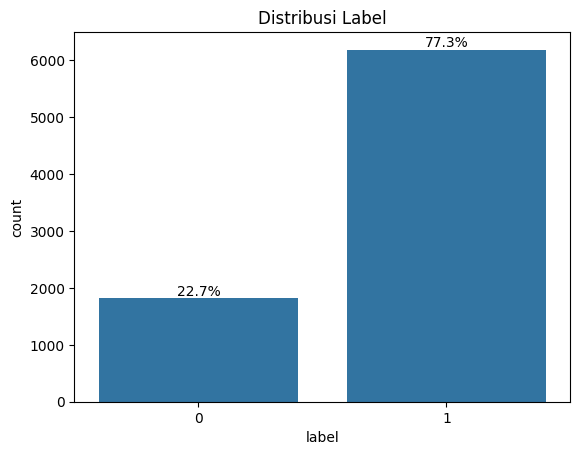

In [430]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='label', data=df)

total = len(df)

for p in ax.patches:
    count = p.get_height()
    pct = 100 * count / total
    ax.text(p.get_x() + p.get_width()/2,
            count + 50,
            f'{pct:.1f}%',
            ha='center')

plt.title('Distribusi Label')
plt.show()

Distribusi label digunakan untuk mengetahui keseimbangan jumlah kelas dalam data agar dapat menentukan apakah diperlukan penanganan khusus pada tahap modeling. Hasil menunjukkan bahwa sekitar 77.3% data termasuk kategori readmission (1), sedangkan 22.7% termasuk tidak readmission (0). Hal ini menunjukkan bahwa data tidak seimbang (imbalanced) karena jumlah kelas 1 jauh lebih dominan dibandingkan kelas 0. Kondisi ini perlu diperhatikan pada tahap modeling agar model tidak cenderung bias terhadap kelas mayoritas.

### **Cek Outlier**

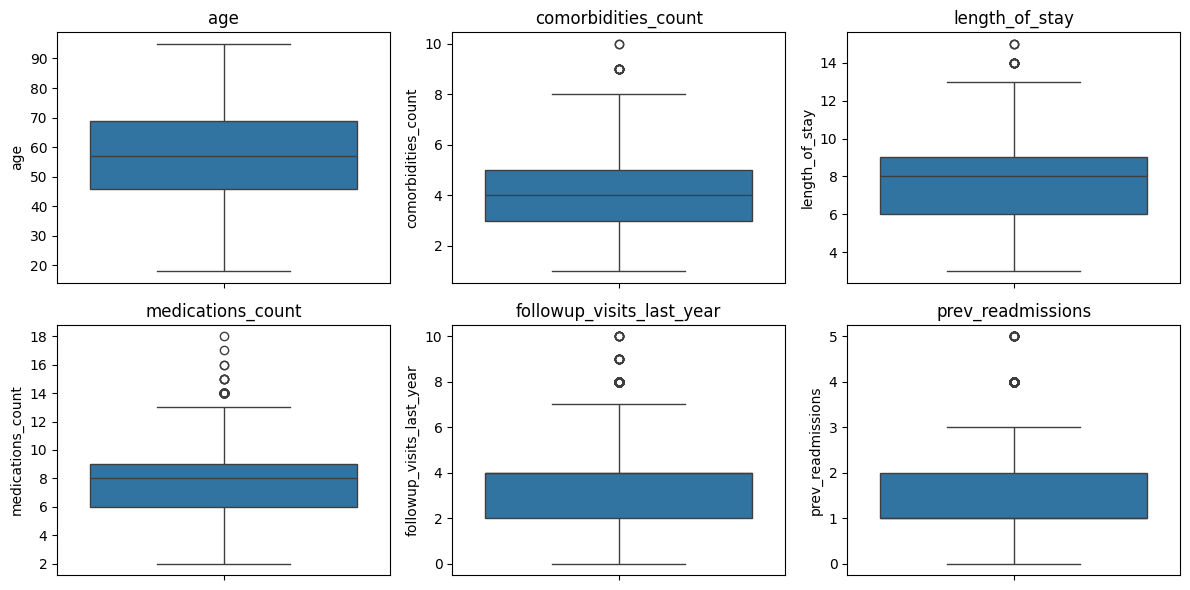

In [431]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil numerik lalu buang 'label'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).drop('label', axis=1).columns

plt.figure(figsize=(12,6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)  # disesuaikan jumlah plotnya
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Dari hasil boxplot terlihat bahwa sebagian besar data berada dalam rentang normal. Variabel age tidak menunjukkan adanya outlier, sehingga distribusinya cukup stabil. Namun, pada beberapa variabel seperti comorbidities_count, length_of_stay, medications_count, followup_visits_last_year, dan prev_readmissions terdapat beberapa nilai yang berada di luar batas (outlier), terutama pada nilai yang lebih tinggi. Hal ini menunjukkan bahwa ada beberapa pasien dengan kondisi yang lebih kompleks, seperti memiliki lebih banyak penyakit, dirawat lebih lama, mengonsumsi lebih banyak obat, serta lebih sering melakukan kunjungan atau rawat inap. Meskipun terdapat outlier, nilainya masih masuk akal dan sesuai dengan kondisi di dunia medis, sehingga data tersebut tetap dipertahankan dan tidak dihapus.

### **Fitur yang Mungkin Menjadi Prediktor yang Baik**

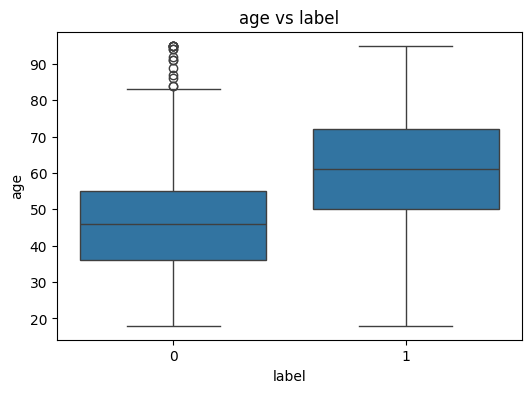

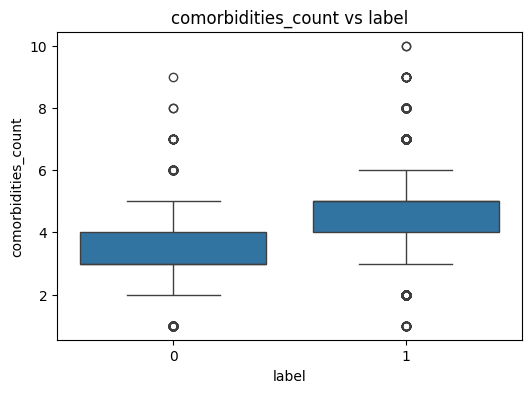

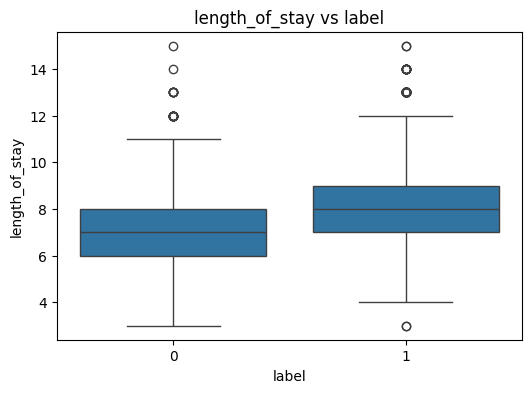

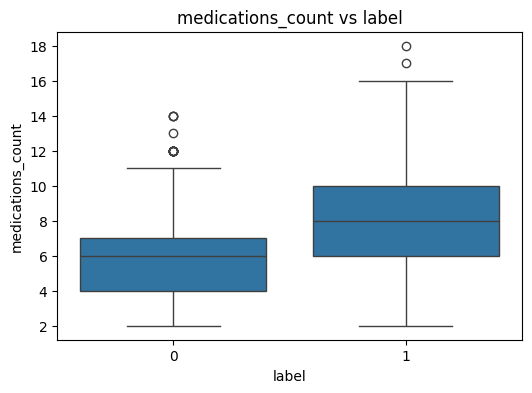

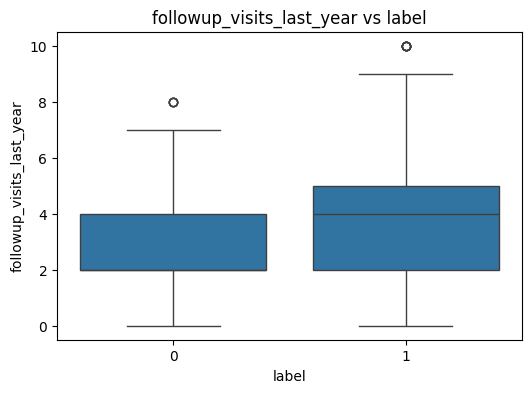

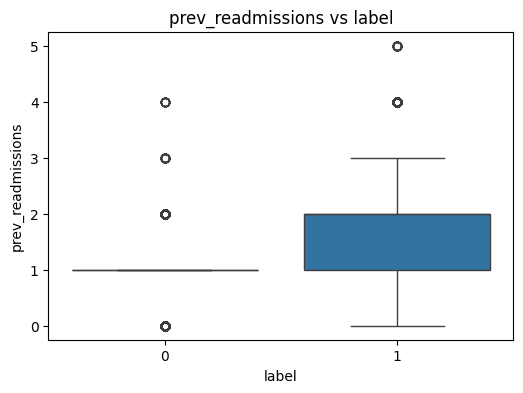

In [432]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'age',
    'comorbidities_count',
    'length_of_stay',
    'medications_count',
    'followup_visits_last_year',
    'prev_readmissions'
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f'{col} vs label')
    plt.show()

Berdasarkan boxplot tersebut, dapat dilihat bahwa ada beberapa fitur yang kemungkinan dapat menjadi prediktor yang baik yaitu:

- prev_readmissions
- medications_count
- age
- comorbidities_count

Selain itu, terdapat fitur lain seperti followup_visits_last_year yang memiliki pengaruh namun tidak terlalu kuat, serta length_of_stay yang menunjukkan pengaruh paling lemah karena distribusi data antar label relatif mirip.

### **Heatmap Korelasi**

Untuk memperkuat analisis sebelumnya mengenai identifikasi faktor-faktor yang berpotensi mempengaruhi terjadinya readmission, dilakukan pengujian korelasi antar variabel numerik guna melihat hubungan masing-masing fitur terhadap variabel target (label).

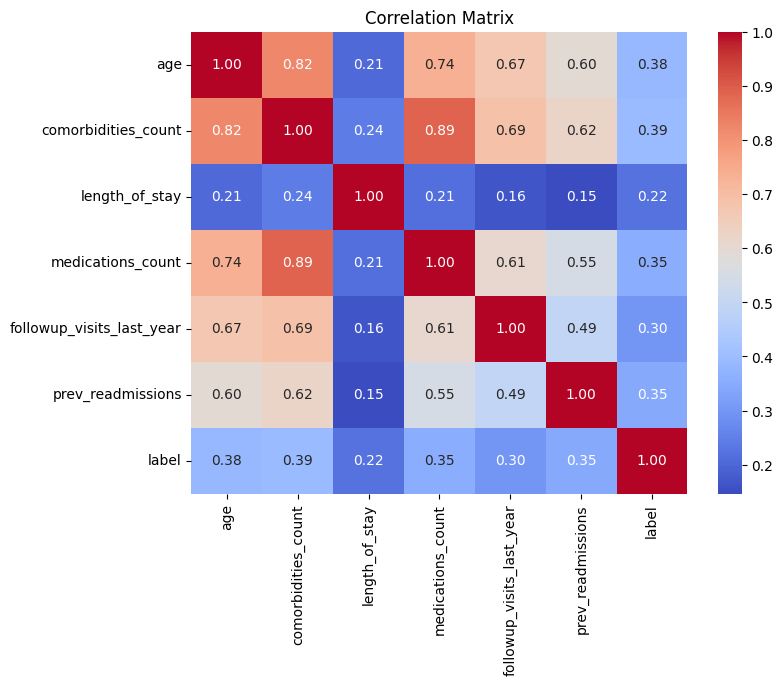

In [433]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'age',
    'comorbidities_count',
    'length_of_stay',
    'medications_count',
    'followup_visits_last_year',
    'prev_readmissions',
    'label'
]

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

Dari matriks korelasi di atas, terlihat bahwa nilai korelasi tertinggi terhadap variabel label terdapat pada comorbidities_count (0.39), diikuti oleh age (0.38). Nilai ini menunjukkan bahwa kedua variabel tersebut memiliki hubungan paling menonjol dibandingkan variabel lainnya dalam mempengaruhi kemungkinan terjadinya readmission. Selain itu, medications_count (0.35) dan prev_readmissions (0.35) juga menunjukkan nilai yang cukup tinggi dan dapat dipertimbangkan sebagai faktor yang berpengaruh. Sehingga variabel seperti comorbidities_count, age, medications_count, dan prev_readmissions dapat dianggap sebagai kandidat prediktor utama dalam memprediksi readmission.


### **Encoding**

Sebelum memasuki tahap pemodelan, dilakukan proses encoding untuk mengubah variabel kategorikal menjadi bentuk numerik agar dapat diproses oleh algoritma machine learning. Variabel yang dilakukan encoding meliputi gender, region, primary_diagnosis, treatment_type, insurance_type, dan discharge_disposition.

**- Gender**

In [434]:
df['gender'] = df['gender'].replace('Male', 1)
df['gender'] = df['gender'].replace('Female', 2)

df['gender'].value_counts()

/tmp/ipykernel_751/1296083310.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace('Female', 2)


,count
gender,
2,4184
1,3816


**- Region**

In [435]:
df['region'] = df['region'].replace('North', 1)
df['region'] = df['region'].replace('South', 2)
df['region'] = df['region'].replace('East', 3)
df['region'] = df['region'].replace('West', 4)
df['region'] = df['region'].replace('Central', 5)

df['region'].value_counts()

/tmp/ipykernel_751/936573653.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['region'] = df['region'].replace('Central', 5)


,count
region,
2,1993
4,1631
3,1617
1,1523
5,1236


**- Primary Diagnosis**

In [436]:
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Diabetes', 1)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Hypertension', 2)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Stroke', 3)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Fracture', 4)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Appendicitis', 5)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Sepsis', 6)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Kidney Disease', 7)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Heart Failure', 8)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('COPD', 9)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Pneumonia', 10)
df['primary_diagnosis'] = df['primary_diagnosis'].replace('Influenza', 11)

df['primary_diagnosis'].value_counts()

/tmp/ipykernel_751/3553016934.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['primary_diagnosis'] = df['primary_diagnosis'].replace('Influenza', 11)


,count
primary_diagnosis,
1,1470
2,1301
9,952
3,883
7,868
5,534
6,497
4,434
10,425


**- Treatment Type**

In [437]:
df['treatment_type'] = df['treatment_type'].replace('Medical', 1)
df['treatment_type'] = df['treatment_type'].replace('Surgical', 2)
df['treatment_type'] = df['treatment_type'].replace('Interventional', 3)
df['treatment_type'] = df['treatment_type'].replace('Conservative', 4)

df['treatment_type'].value_counts()

/tmp/ipykernel_751/1818769772.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['treatment_type'] = df['treatment_type'].replace('Conservative', 4)


,count
treatment_type,
1,3588
2,1988
3,1663
4,761


**- Insurance Type**

In [438]:
df['insurance_type'] = df['insurance_type'].replace('Private', 1)
df['insurance_type'] = df['insurance_type'].replace('Medicare', 2)
df['insurance_type'] = df['insurance_type'].replace('Medicaid', 3)
df['insurance_type'] = df['insurance_type'].replace('Uninsured', 4)

df['insurance_type'].value_counts()

/tmp/ipykernel_751/988132474.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['insurance_type'] = df['insurance_type'].replace('Uninsured', 4)


,count
insurance_type,
1,3052
2,2542
3,1598
4,808


**- Discharge Disposition**

In [439]:
df['discharge_disposition'] = df['discharge_disposition'].replace('Home', 1)
df['discharge_disposition'] = df['discharge_disposition'].replace('Home Health', 2)
df['discharge_disposition'] = df['discharge_disposition'].replace('Skilled Nursing', 3)
df['discharge_disposition'] = df['discharge_disposition'].replace('Rehab', 4)

df['discharge_disposition'].value_counts()

/tmp/ipykernel_751/4025947622.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['discharge_disposition'] = df['discharge_disposition'].replace('Rehab', 4)


,count
discharge_disposition,
2,6065
3,1568
1,317
4,50


**- Season**

In [440]:
df['season'] = df['season'].replace('Spring', 1)
df['season'] = df['season'].replace('Summer', 2)
df['season'] = df['season'].replace('Fall', 3)
df['season'] = df['season'].replace('Winter', 4)

df['season'].value_counts()

/tmp/ipykernel_751/257942266.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['season'] = df['season'].replace('Winter', 4)


,count
season,
4,2041
3,1996
2,1991
1,1972


### **Data Hasil Preprocessing**

Data di bawah ini merupakan dataset yang telah melalui beberapa tahap preprocessing, seperti penghapusan variabel yang tidak relevan, pengecekan missing value, pengecekan data duplikat, serta analisis distribusi dan outlier. Selain itu, telah dilakukan proses encoding pada variabel kategorikal seperti gender, region, primary_diagnosis, treatment_type, insurance_type, dan discharge_disposition sehingga seluruh data telah berada dalam bentuk numerik. Dataset ini sudah lebih bersih dan siap digunakan untuk tahap pemodelan dan analisis lebih lanjut.

In [441]:
df

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,1,66,1,2,1,5,6,3,8,6,1,2,2,1
1,3,55,1,2,1,4,6,3,6,4,3,1,2,1
2,1,69,2,4,2,6,8,1,9,6,2,2,3,1
3,2,83,1,2,3,6,11,1,11,4,2,2,3,1
4,3,54,2,1,3,4,10,1,6,2,1,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,4,95,2,3,9,6,9,3,11,6,2,2,3,1
7996,1,63,2,3,7,4,7,2,7,4,1,3,2,1
7997,2,43,2,3,1,3,6,1,4,2,3,4,2,1
7998,1,86,1,4,6,7,12,3,12,5,3,2,3,1


In [442]:
df.to_csv('data_pasien.csv', index=False)

# **DATA EKSPLORASI**

### **Persentase Pasien Berdasarkan Status Readmission**

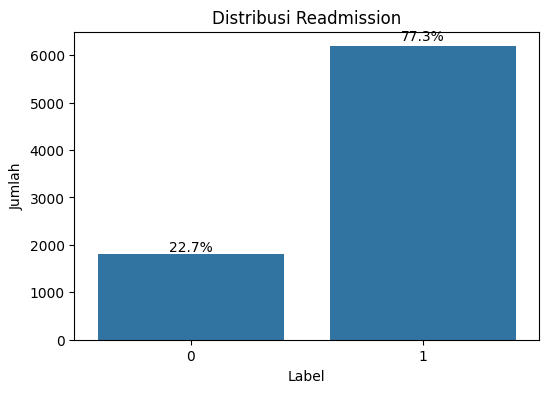

In [443]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.countplot(x='label', data=df)

total = len(df)

for p in ax.patches:
    count = p.get_height()
    pct = 100 * count / total
    ax.text(p.get_x() + p.get_width()/2,
            count + (count * 0.02),
            f'{pct:.1f}%',
            ha='center')

plt.title('Distribusi Readmission')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

Distribusi readmission menunjukkan bahwa sebagian besar pasien berada pada kategori label 1 (mengalami readmission) dengan persentase sekitar 77.3%, sedangkan pasien dengan label 0 (tidak mengalami readmission) hanya sekitar 22.7%. Hal ini menunjukkan bahwa jumlah pasien yang mengalami readmission jauh lebih banyak dibandingkan yang tidak.

### **Distribusi Usia Pasien (Readmission)**

Jumlah data (n): 6183
Min: 18
Max: 95
Jumlah kelas (k): 14
Panjang interval: 6


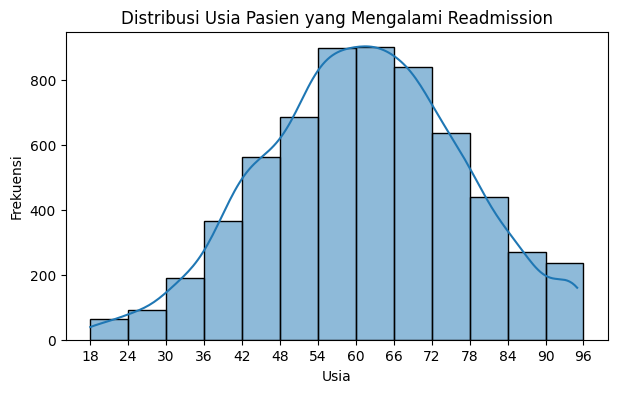

In [444]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

df_readm = df[df['label'] == 1]

n = len(df_readm)
min_val = df_readm['age'].min()
max_val = df_readm['age'].max()

k = 1 + 3.3 * math.log10(n)
k = round(k)

interval = (max_val - min_val) / k
interval = round(interval)  # dibulatkan

print(f"Jumlah data (n): {n}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Jumlah kelas (k): {k}")
print(f"Panjang interval: {interval}")

bins = np.arange(min_val, max_val + interval, interval)

plt.figure(figsize=(7,4))
sns.histplot(df_readm['age'], bins=bins, kde=True)

plt.xticks(bins)
plt.title('Distribusi Usia Pasien yang Mengalami Readmission')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')

plt.show()

Distribusi usia pasien yang mengalami readmission menunjukkan bahwa frekuensi tertinggi berada pada rentang usia 54–60 tahun dan 60–66 tahun, sehingga mayoritas pasien berada pada kelompok usia tersebut. Dimana secara umum memiliki risiko kesehatan lebih tinggi dibandingkan usia muda. Jumlah pasien relatif lebih sedikit pada usia di bawah 30 tahun maupun usia lanjut (di atas 80 tahun).

### **Distribusi Riwayat Pasien (Readmission)**

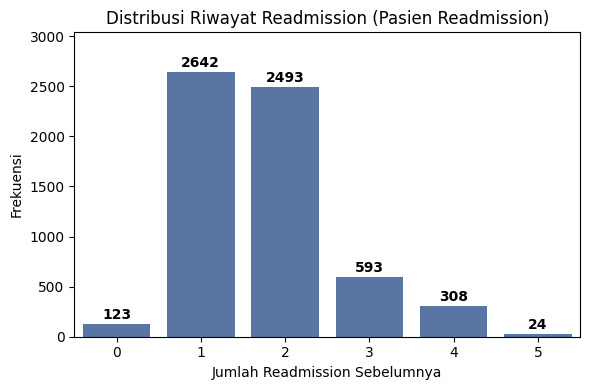

In [445]:
import seaborn as sns
import matplotlib.pyplot as plt

df_readm = df[df['label'] == 1]

plt.figure(figsize=(6,4))
ax = sns.countplot(x='prev_readmissions', data=df_readm, color='#4C72B0')

for p in ax.patches:
    count = int(p.get_height())
    ax.text(p.get_x() + p.get_width()/2,
            count + 50,
            f'{count}',
            ha='center',
            fontsize=10,
            fontweight='bold')

plt.title('Distribusi Riwayat Readmission (Pasien Readmission)', fontsize=12)
plt.xlabel('Jumlah Readmission Sebelumnya')
plt.ylabel('Frekuensi')

plt.ylim(0, max(df_readm['prev_readmissions'].value_counts()) * 1.15)

plt.tight_layout()
plt.show()

Distribusi riwayat readmission pada pasien yang sblmnya juga mengalami readmission menunjukkan bahwa paling banyak pasien memiliki 1 kali dan 2 kali riwayat readmission. Ini berarti sebagian besar pasien yang kembali dirawat sudah pernah mengalami readmission sebelumnya, umumnya dalam jumlah 1–2 kali.

### **Distribusi Komorbiditas (Readmission)**

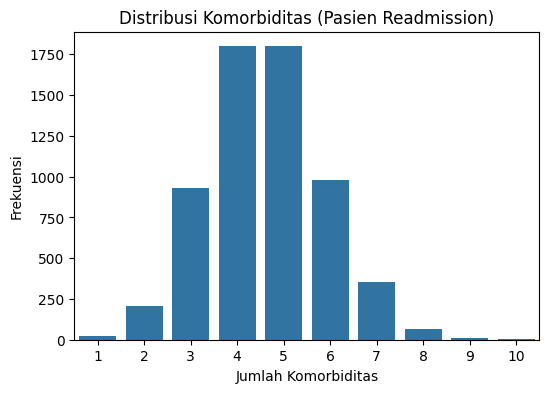

In [446]:
import seaborn as sns
import matplotlib.pyplot as plt

df_readm = df[df['label'] == 1]

plt.figure(figsize=(6,4))
sns.countplot(x='comorbidities_count', data=df_readm)

plt.title('Distribusi Komorbiditas (Pasien Readmission)')
plt.xlabel('Jumlah Komorbiditas')
plt.ylabel('Frekuensi')

plt.show()

Distribusi komorbiditas pada pasien yang mengalami readmission menunjukkan bahwa paling banyak pasien memiliki 4 dan 5 komorbiditas. Ini berarti sebagian besar pasien yang kembali dirawat memiliki beberapa penyakit penyerta dalam jumlah tersebut. Secara umum, pasien readmission didominasi oleh kondisi kesehatan dengan tingkat komorbiditas menengah (sekitar 3–6).

### **Distribusi Jumlah Obat (Readmission)**

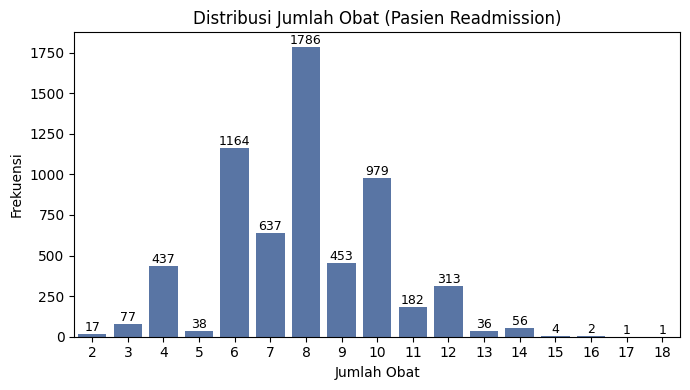

In [447]:
import seaborn as sns
import matplotlib.pyplot as plt

df_readm = df[df['label'] == 1]

plt.figure(figsize=(7,4))
ax = sns.countplot(x='medications_count', data=df_readm, color='#4C72B0')

max_count = df_readm['medications_count'].value_counts().max()

for p in ax.patches:
    count = int(p.get_height())
    ax.text(p.get_x() + p.get_width()/2,
            count + max_count * 0.01,  # proporsional
            f'{count}',
            ha='center',
            fontsize=9)

plt.title('Distribusi Jumlah Obat (Pasien Readmission)')
plt.xlabel('Jumlah Obat')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Distribusi jumlah obat menujukkan jika paling banyak pasien yang mengalami readmission mengonsumsi obat 6-10 jenis obat, dengan mayoritas berada di 8 obat. Artinya, pasien yang mengalami readmission umumnya punya kondisi yang cukup kompleks, karena butuh beberapa jenis obat sekaligus.

# **SPLIT DATA**

Data akan dibagi menjadi dua bagian yaitu 80% data latih (training data) dan 20% data uji (testing data).

In [448]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [449]:
print("=== Data train ===")
X_train.info()

print("\n=== Data test ===")
X_test.info()

=== Data train ===
<class 'pandas.core.frame.DataFrame'>
Index: 6400 entries, 7989 to 126
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   season                     6400 non-null   int64
 1   age                        6400 non-null   int64
 2   gender                     6400 non-null   int64
 3   region                     6400 non-null   int64
 4   primary_diagnosis          6400 non-null   int64
 5   comorbidities_count        6400 non-null   int64
 6   length_of_stay             6400 non-null   int64
 7   treatment_type             6400 non-null   int64
 8   medications_count          6400 non-null   int64
 9   followup_visits_last_year  6400 non-null   int64
 10  prev_readmissions          6400 non-null   int64
 11  insurance_type             6400 non-null   int64
 12  discharge_disposition      6400 non-null   int64
dtypes: int64(13)
memory usage: 700.0 KB

=== Data test ===
<class 

Dari pembagian data dengan perbandingan 80% dan 20%, diperoleh sebanyak 6400 data sebagai data latih dan 1600 data sebagai data uji, di mana sebagian besar data digunakan untuk melatih model dan sisanya digunakan untuk pengujian.

# **MODELLING**

In [450]:
df

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,label
0,1,66,1,2,1,5,6,3,8,6,1,2,2,1
1,3,55,1,2,1,4,6,3,6,4,3,1,2,1
2,1,69,2,4,2,6,8,1,9,6,2,2,3,1
3,2,83,1,2,3,6,11,1,11,4,2,2,3,1
4,3,54,2,1,3,4,10,1,6,2,1,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,4,95,2,3,9,6,9,3,11,6,2,2,3,1
7996,1,63,2,3,7,4,7,2,7,4,1,3,2,1
7997,2,43,2,3,1,3,6,1,4,2,3,4,2,1
7998,1,86,1,4,6,7,12,3,12,5,3,2,3,1


Pada tahap pemodelan, digunakan beberapa algoritma klasifikasi untuk membangun model dalam menganalisis data readmission. Model yang digunakan terdiri dari empat metode, yaitu
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

### **Regresi Logistik**

In [451]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

hasil_prediksi = model.predict(X_test)

cm = confusion_matrix(y_test, hasil_prediksi)
akurasi = accuracy_score(y_test, hasil_prediksi)
precision = precision_score(y_test, hasil_prediksi)
recall = recall_score(y_test, hasil_prediksi)
f1 = f1_score(y_test, hasil_prediksi)

prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, prob)

print("Confusion Matrix:\n", cm)
print("Akurasi:", round(akurasi,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("ROC AUC:", round(auc,3))

Confusion Matrix:
 [[ 111  252]
 [  57 1180]]
Akurasi: 0.807
Precision: 0.824
Recall: 0.954
F1 Score: 0.884
ROC AUC: 0.817


Berdasarkan hasil klasifikasi menggunakan metode Logistic Regression, diperoleh nilai accuracy sebesar 80.7%, precision 82.4%, recall 95.4%, dan F1-score 88.4%. Hasil ini sudah cukup baik, terutama karena model mampu mengenali sebagian besar pasien yang mengalami readmission, terlihat dari nilai recall yang tinggi. Nilai ROC-AUC sebesar 0.817 juga memperlihatkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan kedua kelas.

### **K-Nearest Neighbors (KNN)**

In [452]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

hasil_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, hasil_knn)
akurasi_knn = accuracy_score(y_test, hasil_knn)
precision = precision_score(y_test, hasil_knn)
recall = recall_score(y_test, hasil_knn)
f1 = f1_score(y_test, hasil_knn)

prob = knn.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, prob)

print("Confusion Matrix:\n", cm)
print("Akurasi:", round(akurasi_knn,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("ROC AUC:", round(auc,3))

Confusion Matrix:
 [[ 141  222]
 [ 141 1096]]
Akurasi: 0.773
Precision: 0.832
Recall: 0.886
F1 Score: 0.858
ROC AUC: 0.743


Berdasarkan hasil klasifikasi menggunakan metode K-Nearest Neighbors (KNN), diperoleh nilai accuracy sebesar 77.3%, precision 83.2%, recall 88.6%, dan F1-score 85.8%. Hasil ini sudah cukup baik, di mana model mampu mengenali sebagian besar pasien yang mengalami readmission dengan cukup tinggi. Nilai ROC-AUC sebesar 0.743 menunjukkan bahwa kemampuan model dalam membedakan kedua kelas tergolong cukup, meskipun tidak sebaik model sebelumnya.

### **Decision Tree**

In [453]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

hasil_dt = dt.predict(X_test)

cm = confusion_matrix(y_test, hasil_dt)
akurasi_dt = accuracy_score(y_test, hasil_dt)
precision = precision_score(y_test, hasil_dt)
recall = recall_score(y_test, hasil_dt)
f1 = f1_score(y_test, hasil_dt)

prob = dt.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, prob)

print("Confusion Matrix:\n", cm)
print("Akurasi:", round(akurasi_dt,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("ROC AUC:", round(auc,3))

Confusion Matrix:
 [[ 148  215]
 [ 234 1003]]
Akurasi: 0.719
Precision: 0.823
Recall: 0.811
F1 Score: 0.817
ROC AUC: 0.609


Berdasarkan hasil klasifikasi menggunakan metode Decision Tree, diperoleh nilai accuracy sebesar 71.9%, precision 82.3%, recall 81.1%, serta F1-score 81.7%. Model ini sudah cukup mampu dalam melakukan klasifikasi, meskipun tingkat akurasinya masih belum terlalu tinggi. Jika dilihat dari nilai precision dan recall yang cukup seimbang, model ini sebenarnya sudah cukup baik dalam mengidentifikasi kedua kelas. Namun, nilai ROC-AUC sebesar 0.609 menunjukkan bahwa kemampuan model dalam membedakan antara pasien yang mengalami readmission dan yang tidak masih tergolong rendah.

### **Random Forest**

In [454]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

hasil_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, hasil_rf)
akurasi_rf = accuracy_score(y_test, hasil_rf)
precision = precision_score(y_test, hasil_rf)
recall = recall_score(y_test, hasil_rf)
f1 = f1_score(y_test, hasil_rf)

prob = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, prob)

print("Confusion Matrix:\n", cm)
print("Akurasi:", round(akurasi,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))
print("ROC AUC:", round(auc,3))

Confusion Matrix:
 [[ 123  240]
 [  91 1146]]
Akurasi: 0.807
Precision: 0.827
Recall: 0.926
F1 Score: 0.874
ROC AUC: 0.808


Berdasarkan hasil klasifikasi menggunakan metode Random Forest, diperoleh nilai accuracy sebesar 79.3%, precision 82.7%, recall 92.6%, dan F1-score 87.4%. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan data dengan cukup baik, terutama dalam mengenali pasien yang mengalami readmission yang terlihat dari nilai recall yang tinggi. Nilai ROC-AUC sebesar 0.808 menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam membedakan kedua kelas.

### **Accuracy**

In [455]:
import pandas as pd

data = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy (%)': [80.7, 77.3, 71.9, 79.3]
}

tabel = pd.DataFrame(data)

tabel

,Model,Accuracy (%)
0,Logistic Regression,80.7
1,KNN,77.3
2,Decision Tree,71.9
3,Random Forest,79.3


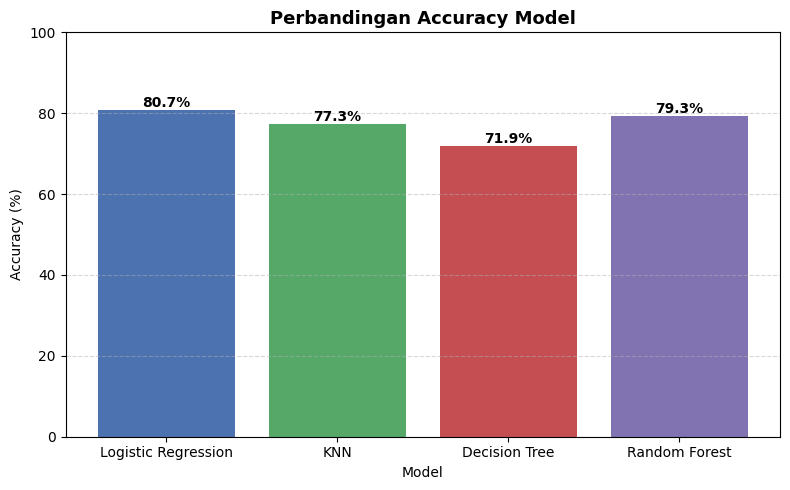

In [456]:
import matplotlib.pyplot as plt

model = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
accuracy = [
    akurasi * 100,
    akurasi_knn * 100,
    akurasi_dt * 100,
    akurasi_rf * 100
]

plt.figure(figsize=(8,5))
bars = plt.bar(model, accuracy, color=['#4C72B0','#55A868','#C44E52','#8172B2'])

# label angka
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.8,
             f'{yval:.1f}%',
             ha='center',
             fontsize=10,
             fontweight='bold')

plt.title('Perbandingan Accuracy Model', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')

plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Berdasarkan perbandingan nilai accuracy dari keempat model, Logistic Regression memiliki nilai accuracy tertinggi yaitu sebesar 80.7%. Dengan hasil tersebut, model ini menjadi yang paling baik dibandingkan KNN, Decision Tree, dan Random Forest dalam mengklasifikasikan data.


### **Model Benchmarking : K-Fold**

Untuk memperoleh evaluasi yang lebih akurat dan stabil, digunakan metode k-fold cross-validation sebagai pendekatan benchmarking model. Metode ini bertujuan untuk membandingkan performa beberapa model machine learning secara lebih menyeluruh, sehingga hasil yang diperoleh tidak bergantung pada satu pembagian data saja.

Dalam k-fold cross-validation, data dibagi menjadi beberapa bagian (fold) dengan ukuran yang sama. Selanjutnya, proses pelatihan dan pengujian dilakukan secara berulang, di mana pada setiap iterasi sebagian data digunakan sebagai data latih dan sisanya sebagai data uji. Nilai performa dari setiap iterasi kemudian dirata-ratakan untuk mendapatkan gambaran kinerja model secara keseluruhan.

In [457]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

hasil = []

for nama, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='roc_auc')
    hasil.append([nama, scores.mean(), scores.std()])

df_hasil = pd.DataFrame(hasil, columns=['Model', 'Mean ROC AUC', 'Std ROC AUC'])

# urutkan dari terbaik
df_hasil = df_hasil.sort_values(by='Mean ROC AUC', ascending=False)

df_hasil

,Model,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,0.820624,0.011931
3,Random Forest,0.807442,0.018796
1,KNN,0.746703,0.013218
2,Decision Tree,0.614426,0.014982


Berdasarkan hasil evaluasi menggunakan metode k-fold cross-validation dengan metrik ROC-AUC, terlihat bahwa Logistic Regression memiliki nilai rata-rata ROC-AUC tertinggi yaitu sebesar 0.8206, sehingga menjadi model dengan performa terbaik dalam membedakan antara pasien yang mengalami readmission dan yang tidak. Di antara model yang ada, Logistic Regression memiliki standar deviasi yang paling kecil (0.0119), yang menunjukkan bahwa performanya paling stabil dibandingkan model lainnya.

### **Model Benchmarking : Data Testing**

Sebagai tambahan evaluasi, dilakukan model benchmarking menggunakan data testing untuk melihat performa masing-masing model pada data yang tidak digunakan selama proses pelatihan. Dengan cara ini, bisa diketahui bagaimana kemampuan model dalam menggeneralisasi data baru yang belum pernah dilihat sebelumnya.

Evaluasi dilakukan menggunakan beberapa metrik, yaitu ROC-AUC, Recall, dan False Positive Rate (FPR). ROC-AUC digunakan untuk melihat seberapa baik model dalam membedakan antara dua kelas, di mana nilai yang lebih tinggi menandakan performa yang lebih baik. Recall digunakan untuk mengukur kemampuan model dalam menangkap data positif, sehingga semakin tinggi nilainya semakin baik. Sedangkan FPR digunakan untuk melihat seberapa sering model salah mengklasifikasikan data negatif sebagai positif, sehingga nilai yang lebih rendah lebih diharapkan. Dengan membandingkan nilai dari ketiga metrik tersebut, dapat diketahui model mana yang memiliki performa paling baik dalam mengklasifikasikan data testing.

In [458]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, recall_score
import pandas as pd

model = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(n_neighbors=5),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42)
]

algo = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

roc_auc = []
recall = []
fpr = []

for i, m in enumerate(model):
    pipe = Pipeline([('model', m)])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    cm = confusion_matrix(y_test, y_pred)

    roc_auc.append(roc_auc_score(y_test, y_proba))
    recall.append(recall_score(y_test, y_pred))
    fpr.append(cm[0][1] / (cm[0][1] + cm[0][0]))

    print(f"\n=== {algo[i]} ===")
    print(classification_report(y_test, y_pred))

df_hasil = pd.DataFrame({
    'Model': algo,
    'ROC AUC': roc_auc,
    'Recall': recall,
    'FPR': fpr
}).sort_values(by='ROC AUC', ascending=False)

df_hasil


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.66      0.31      0.42       363
           1       0.82      0.95      0.88      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.63      0.65      1600
weighted avg       0.79      0.81      0.78      1600


=== KNN ===
              precision    recall  f1-score   support

           0       0.50      0.39      0.44       363
           1       0.83      0.89      0.86      1237

    accuracy                           0.77      1600
   macro avg       0.67      0.64      0.65      1600
weighted avg       0.76      0.77      0.76      1600


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.39      0.41      0.40       363
           1       0.82      0.81      0.82      1237

    accuracy                           0.72      1600
   macro avg       0.61      0.61      0.61      1600
weighted 

,Model,ROC AUC,Recall,FPR
0,Logistic Regression,0.816574,0.953921,0.694215
3,Random Forest,0.807542,0.926435,0.661157
1,KNN,0.742993,0.886015,0.611570
2,Decision Tree,0.609273,0.810833,0.592287


Hasil benchmarking pada data testing menunjukkan bahwa Logistic Regression memiliki performa terbaik dengan nilai ROC-AUC sekitar 0.817, diikuti oleh Random Forest dengan nilai yang tidak jauh berbeda. Nilai recall, Logistic Regression juga paling tinggi, sehingga mampu menangkap sebagian besar kasus readmission. KNN dan Decision Tree memiliki performa yang lebih rendah dibandingkan kedua model tersebut. Namun, seluruh model masih memiliki nilai FPR yang cukup tinggi, sehingga masih sering terjadi kesalahan pada data negatif. Model Logistic Regression menjadi pilihan terbaik karena memiliki kombinasi performa yang paling unggul meskipun masih perlu perbaikan pada FPR.

### **Oversampling Test**

Dari tahap sebelumnya diketahui bahwa data yang digunakan memiliki kondisi tidak seimbang (imbalance), sehingga model cenderung lebih dominan memprediksi ke kelas tertentu. Kondisi ini bisa mempengaruhi hasil model, terutama dalam mendeteksi kelas yang jumlahnya lebih sedikit. Untuk mengatasi hal tersebut, digunakan teknik oversampling, yaitu dengan menambah jumlah data pada kelas minoritas agar distribusi data menjadi lebih seimbang. Dengan data yang lebih seimbang, model diharapkan dapat belajar dengan lebih baik dan tidak bias terhadap salah satu kelas saja.

Pada penelitian ini, metode oversampling yang digunakan adalah SMOTE (Synthetic Minority Over-sampling Technique), yaitu dengan membuat data sintetis berdasarkan pola dari data yang sudah ada, bukan hanya menduplikasi data. Setelah data dibagi menjadi data training dan data testing, proses oversampling diterapkan pada data training agar model dapat dilatih dengan data yang sudah seimbang, sementara data testing tetap digunakan sebagai data evaluasi.

In [459]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:\n", y_train.value_counts())
print("\nSesudah SMOTE:\n", y_train_smote.value_counts())

Sebelum SMOTE:
 label
1    4946
0    1454
Name: count, dtype: int64

Sesudah SMOTE:
 label
1    4946
0    4946
Name: count, dtype: int64


In [460]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

print("Ukuran dataset:", df.shape)
print("\nDistribusi label:")
print(y.value_counts())
print("\nPersentase:")
print((y.value_counts()/len(y))*100)

Ukuran dataset: (8000, 14)

Distribusi label:
label
1    6183
0    1817
Name: count, dtype: int64

Persentase:
label
1    77.2875
0    22.7125
Name: count, dtype: float64


**- Training**

In [461]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

models = [
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(n_neighbors=5),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42)
]

nama_model = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']

score = []
score_avg = []
std = []

sampling = SMOTE(random_state=42)
X_train_smote, y_train_smote = sampling.fit_resample(X_train, y_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for a in models:

    pipeline_model = Pipeline([('model', a)])

    model_cv = cross_val_score(
        pipeline_model,
        X_train_smote,
        y_train_smote,
        cv=skf,
        scoring='roc_auc'
    )

    score.append([round(i, 3) for i in model_cv])
    score_avg.append(model_cv.mean())
    std.append(model_cv.std())

print("Ukuran data training:", y_train_smote.shape)
display(y_train_smote.value_counts())
display((y_train_smote.value_counts()/len(y_train_smote))*100)

df_train = pd.DataFrame({
    'Model': nama_model,
    'Mean ROC AUC': score_avg,
    'Std ROC AUC': std
}).set_index('Model').sort_values(by='Mean ROC AUC', ascending=False)

df_train

Ukuran data training: (9892,)


,count
label,
1,4946
0,4946


,count
label,
1,50.0
0,50.0


,Mean ROC AUC,Std ROC AUC
Model,,
Random Forest,0.936893,0.002988
KNN,0.899431,0.003472
Logistic Regression,0.872006,0.004788
Decision Tree,0.801255,0.004065


**- Testing**

In [462]:
from sklearn.metrics import *

recall = []
fpr_test = []
roc_auc_test = []

for i, a in enumerate(models):

    pipeline_model = Pipeline([('model', a)])

    pipeline_model.fit(X_train_smote, y_train_smote)

    y_pred = pipeline_model.predict(X_test)
    y_prob = pipeline_model.predict_proba(X_test)[:,1]

    cm = confusion_matrix(y_test, y_pred)

    recall.append(recall_score(y_test, y_pred))
    fpr_test.append(cm[0][1] / (cm[0][1] + cm[0][0]))
    roc_auc_test.append(roc_auc_score(y_test, y_prob))

    print(f"\n=== {nama_model[i]} ===")
    print(classification_report(y_test, y_pred))

print("\nUkuran data testing:", y_test.shape)
display(y_test.value_counts())
display((y_test.value_counts()/len(y_test))*100)

df_test = pd.DataFrame({
    'Model': nama_model,
    'ROC AUC': roc_auc_test,
    'Recall': recall,
    'FPR': fpr_test
}).set_index('Model').sort_values(by='ROC AUC', ascending=False)

df_test


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.46      0.66      0.54       363
           1       0.88      0.77      0.82      1237

    accuracy                           0.74      1600
   macro avg       0.67      0.71      0.68      1600
weighted avg       0.79      0.74      0.76      1600


=== KNN ===
              precision    recall  f1-score   support

           0       0.40      0.66      0.50       363
           1       0.88      0.70      0.78      1237

    accuracy                           0.69      1600
   macro avg       0.64      0.68      0.64      1600
weighted avg       0.77      0.69      0.72      1600


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.39      0.50      0.44       363
           1       0.84      0.77      0.80      1237

    accuracy                           0.71      1600
   macro avg       0.62      0.64      0.62      1600
weighted 

,count
label,
1,1237
0,363


,count
label,
1,77.3125
0,22.6875


,ROC AUC,Recall,FPR
Model,,,
Logistic Regression,0.795889,0.769604,0.344353
Random Forest,0.793795,0.834276,0.473829
KNN,0.731326,0.701698,0.336088
Decision Tree,0.637676,0.771221,0.495868


Pada data training yang sudah dilakukan oversampling menggunakan metode SMOTE, distribusi kelas menjadi seimbang (50:50), sehingga model bisa belajar dengan lebih baik tanpa condong ke salah satu kelas. Berdasarkan hasil evaluasi menggunakan K-Fold, Random Forest memiliki performa paling baik dengan nilai ROC-AUC tertinggi, diikuti oleh KNN dan Logistic Regression, sedangkan Decision Tree memiliki performa paling rendah.

Namun, pada data testing hasilnya sedikit berbeda, di mana Logistic Regression justru memberikan performa terbaik dengan nilai ROC-AUC yang lebih tinggi dan FPR yang lebih rendah dibanding Random Forest. Walaupun Random Forest memiliki recall yang lebih tinggi, nilai FPR-nya juga cukup besar sehingga masih sering salah dalam mengklasifikasikan data negatif. Secara keseluruhan, Logistic Regression terlihat lebih stabil karena mampu menjaga keseimbangan antara kemampuan mendeteksi kelas positif dan meminimalkan kesalahan prediksi, sedangkan Random Forest cenderung terlalu menyesuaikan diri dengan data training.

### **Undersampling Test**

Selain menggunakan oversampling, penanganan data yang tidak seimbang juga bisa dilakukan dengan metode undersampling, yaitu dengan mengurangi jumlah data pada kelas mayoritas agar distribusinya menjadi lebih seimbang. Dengan cara ini, model diharapkan tidak terlalu condong ke kelas yang jumlahnya lebih banyak. Pada penelitian ini digunakan metode Random UnderSampler, di mana sebagian data dari kelas mayoritas diambil secara acak hingga jumlahnya seimbang dengan kelas minoritas.

In [463]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import pandas as pd

score = []
score_avg = []
std = []

# undersampling
rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for a in models:

    pipeline_model = Pipeline([('model', a)])

    model_cv = cross_val_score(
        pipeline_model,
        X_train_under,
        y_train_under,
        cv=skf,
        scoring='roc_auc'
    )

    score.append([round(i, 3) for i in model_cv])
    score_avg.append(model_cv.mean())
    std.append(model_cv.std())

print("Ukuran data training (undersampling):", y_train_under.shape)
display(y_train_under.value_counts())
display((y_train_under.value_counts()/len(y_train_under))*100)

df_train_under = pd.DataFrame({
    'Model': nama_model,
    'Mean ROC AUC': score_avg,
    'Std ROC AUC': std
}).set_index('Model').sort_values(by='Mean ROC AUC', ascending=False)

df_train_under

Ukuran data training (undersampling): (2908,)


,count
label,
0,1454
1,1454


,count
label,
0,50.0
1,50.0


,Mean ROC AUC,Std ROC AUC
Model,,
Logistic Regression,0.817022,0.008205
Random Forest,0.797020,0.006347
KNN,0.747775,0.017849
Decision Tree,0.653054,0.015712


In [464]:
from sklearn.metrics import *

recall = []
fpr_test = []
roc_auc_test = []

for i, a in enumerate(models):

    pipeline_model = Pipeline([('model', a)])

    # training pakai undersampling
    pipeline_model.fit(X_train_under, y_train_under)

    # testing pakai data asli
    y_pred = pipeline_model.predict(X_test)
    y_prob = pipeline_model.predict_proba(X_test)[:,1]

    cm = confusion_matrix(y_test, y_pred)

    recall.append(recall_score(y_test, y_pred))
    fpr_test.append(cm[0][1] / (cm[0][1] + cm[0][0]))
    roc_auc_test.append(roc_auc_score(y_test, y_prob))

    print(f"\n=== {nama_model[i]} ===")
    print(classification_report(y_test, y_pred))

print("\nUkuran data testing:", y_test.shape)
display(y_test.value_counts())
display((y_test.value_counts()/len(y_test))*100)

df_test_under = pd.DataFrame({
    'Model': nama_model,
    'ROC AUC': roc_auc_test,
    'Recall': recall,
    'FPR': fpr_test
}).set_index('Model').sort_values(by='ROC AUC', ascending=False)

df_test_under


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.45      0.78      0.57       363
           1       0.92      0.72      0.81      1237

    accuracy                           0.73      1600
   macro avg       0.68      0.75      0.69      1600
weighted avg       0.81      0.73      0.75      1600


=== KNN ===
              precision    recall  f1-score   support

           0       0.38      0.73      0.49       363
           1       0.89      0.64      0.75      1237

    accuracy                           0.66      1600
   macro avg       0.63      0.69      0.62      1600
weighted avg       0.77      0.66      0.69      1600


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.34      0.63      0.44       363
           1       0.85      0.64      0.73      1237

    accuracy                           0.64      1600
   macro avg       0.60      0.63      0.59      1600
weighted 

,count
label,
1,1237
0,363


,count
label,
1,77.3125
0,22.6875


,ROC AUC,Recall,FPR
Model,,,
Logistic Regression,0.816204,0.720291,0.223140
Random Forest,0.802939,0.714632,0.245179
KNN,0.748954,0.644301,0.272727
Decision Tree,0.633775,0.639450,0.371901


Setelah dilakukan undersampling, performa model terlihat cukup membaik, terutama pada nilai ROC-AUC dan recall. Logistic Regression memiliki performa terbaik dengan nilai ROC-AUC tertinggi, diikuti oleh Random Forest dan KNN, sedangkan Decision Tree masih menjadi yang terendah. Dikarenakan metode terbaik yang diperoleh dari hasil oversampling dan undersampling menunjukkan bahwa Logistic Regression memiliki performa yang paling baik, maka pada tahap selanjutnya metode tersebut dipilih untuk digunakan dalam pembangunan model akhir.

### **Hyperparameter Tuning**

Pada tahap ini dilakukan proses hyperparameter tuning untuk meningkatkan performa model yang telah diperoleh sebelumnya. Proses ini bertujuan untuk mencari kombinasi parameter terbaik agar model dapat bekerja lebih optimal dalam melakukan klasifikasi. Metode yang digunakan adalah GridSearchCV, dengan fokus pada model Logistic Regression yang sebelumnya menunjukkan performa paling baik.

In [465]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

lr = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

best_model = grid.best_estimator_

print("Best Parameter:", grid.best_params_)
print("Best ROC AUC (CV):", grid.best_score_)

Best Parameter: {'C': 1, 'solver': 'liblinear'}
Best ROC AUC (CV): 0.8708562410721552


Hasil tuning menghasilkan parameter terbaik pada C = 1 dengan solver *liblinear*, yang berarti konfigurasi awal model sudah cukup optimal. Nilai ROC-AUC sebesar 0.8708 pada cross-validation menandakan kemampuan model dalam membedakan kedua kelas sudah tergolong baik.

In [466]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix
import pandas as pd

# =========================
# 1. MODEL DEFAULT
# =========================
model_default = LogisticRegression(max_iter=1000)
model_default.fit(X_train_smote, y_train_smote)

y_pred_def = model_default.predict(X_test)
y_prob_def = model_default.predict_proba(X_test)[:,1]

cm_def = confusion_matrix(y_test, y_pred_def)

recall_def = recall_score(y_test, y_pred_def)
fpr_def = cm_def[0][1] / (cm_def[0][1] + cm_def[0][0])
roc_def = roc_auc_score(y_test, y_prob_def)

# =========================
# 2. MODEL TUNED (hasil GridSearch)
# =========================
model_tuned = grid.best_estimator_

y_pred_tuned = model_tuned.predict(X_test)
y_prob_tuned = model_tuned.predict_proba(X_test)[:,1]

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

recall_tuned = recall_score(y_test, y_pred_tuned)
fpr_tuned = cm_tuned[0][1] / (cm_tuned[0][1] + cm_tuned[0][0])
roc_tuned = roc_auc_score(y_test, y_prob_tuned)

# =========================
# 3. TABEL PERBANDINGAN
# =========================
df_compare = pd.DataFrame({
    'Recall': [recall_def, recall_tuned],
    'FPR': [fpr_def, fpr_tuned],
    'ROC AUC': [roc_def, roc_tuned]
}, index=['Default Model', 'Tuned Model'])

df_compare


,Recall,FPR,ROC AUC
Default Model,0.769604,0.344353,0.795889
Tuned Model,0.770412,0.347107,0.796624


Setelah dilakukan hyperparameter tuning, performa model tidak mengalami perubahan yang signifikan dibandingkan model default. Nilai recall dan ROC-AUC hanya meningkat sedikit, namun FPR justru sedikit lebih tinggi, sehingga kesalahan pada data negatif masih relatif sama. Secara keseluruhan, tuning tidak memberikan peningkatan yang berarti terhadap performa model.

### **Feature Importance**

Pada tahap ini dilakukan analisis terhadap fitur-fitur yang digunakan dalam model untuk mengetahui variabel mana yang paling berpengaruh terhadap prediksi readmission. Analisis ini dilakukan berdasarkan nilai koefisien dari model Logistic Regression yang telah dipilih sebagai model terbaik. Dengan melihat besar dan arah koefisien, dapat diketahui apakah suatu fitur memiliki pengaruh positif atau negatif terhadap kemungkinan readmission.

In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_final = grid.best_estimator_

coef = model_final.coef_[0]

feature_names = X.columns

df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
})

df_coef['Abs'] = np.abs(df_coef['Coefficient'])
df_coef = df_coef.sort_values(by='Abs', ascending=False).drop(columns='Abs')

df_coef

,Feature,Coefficient
10,prev_readmissions,1.189196
2,gender,0.560913
5,comorbidities_count,0.406305
11,insurance_type,0.286126
7,treatment_type,0.273534
6,length_of_stay,0.270544
12,discharge_disposition,-0.264868
9,followup_visits_last_year,0.179751
3,region,0.116014
8,medications_count,0.094853


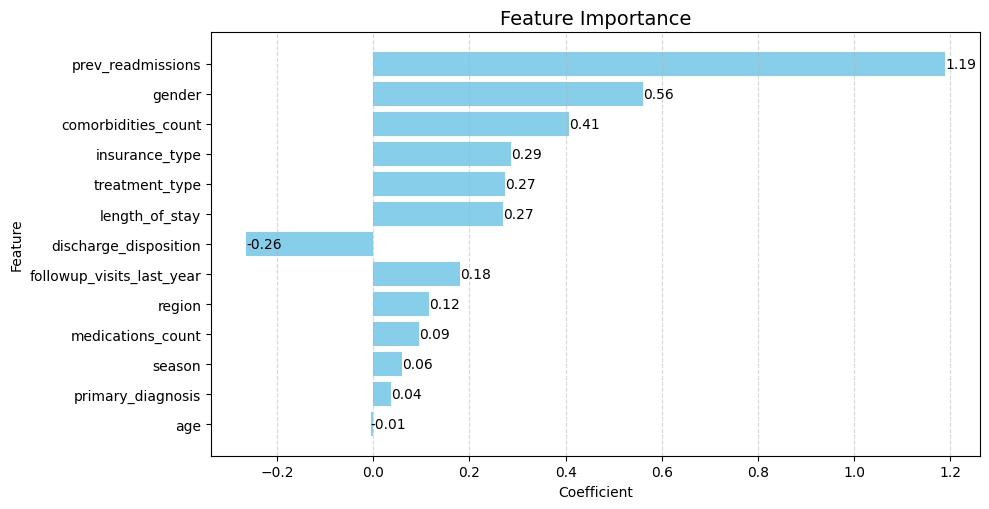

In [468]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, len(df_coef)*0.4))  # tinggi otomatis menyesuaikan jumlah fitur

bars = plt.barh(
    df_coef['Feature'],
    df_coef['Coefficient'],
    color='skyblue'
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center')

plt.title('Feature Importance', fontsize=14)
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Variabel prev_readmissions merupakan fitur yang paling berpengaruh dalam memprediksi readmission, sehingga riwayat pasien yang pernah mengalami readmission sebelumnya memiliki pengaruh yang sangat besar terhadap kemungkinan terjadinya readmission kembali. Selain itu, terdapat variabel lain seperti gender dan comorbidities_count yang juga cukup berpengaruh, yang menunjukkan bahwa karakteristik pasien serta kondisi kesehatan yang dimiliki turut memengaruhi peluang readmission. Selanjutnya, variabel seperti length_of_stay, treatment_type, dan insurance_type juga memberikan kontribusi meskipun tidak sebesar variabel utama. Sementara itu, variabel discharge_disposition dan age memiliki arah pengaruh yang berlawanan, sehingga cenderung berkaitan dengan penurunan kemungkinan terjadinya readmission.


# **KESIMPULAN**

Berdasarkan seluruh rangkaian analisis yang telah dilakukan, mulai dari pemodelan awal, penanganan data imbalance menggunakan oversampling dan undersampling, hingga proses hyperparameter tuning, diperoleh bahwa model Logistic Regression memberikan performa yang paling stabil dan konsisten dibandingkan model lainnya. Meskipun beberapa model seperti Random Forest menunjukkan hasil yang tinggi pada data training, performanya tidak sebaik Logistic Regression ketika diuji pada data testing. Proses oversampling dan undersampling membantu meningkatkan kemampuan model dalam mengenali kelas minoritas, namun peningkatannya tidak terlalu signifikan. Selain itu, hasil hyperparameter tuning juga tidak memberikan perubahan yang besar terhadap performa model. Berdasarkan analisis feature importance, diketahui bahwa variabel seperti prev_readmissions, gender, dan comorbidities_count menjadi faktor yang paling berpengaruh terhadap kemungkinan terjadinya readmission. Dengan adanya model ini, pihak rumah sakit dapat lebih awal mengidentifikasi pasien yang berpotensi mengalami readmission, sehingga bisa dilakukan tindakan pencegahan atau monitoring lebih lanjut

# **REKOMENDASI**

### **- Rekomendasi Untuk Model**

1. Penambahan Data: Model dapat ditingkatkan dengan menambahkan jumlah data pasien, terutama pada kelas minoritas, agar model dapat belajar pola dengan lebih baik dan menghasilkan prediksi yang lebih akurat.
2. Pengembangan Fitur: Perlu dilakukan eksplorasi fitur tambahan atau pengolahan fitur yang lebih dalam, misalnya menggabungkan beberapa variabel atau membuat fitur baru yang lebih representatif terhadap kondisi pasien.
3. Eksplorasi Model Lain: Meskipun Logistic Regression sudah cukup stabil, tetap memungkinkan untuk mencoba model lain atau pendekatan yang lebih kompleks untuk melihat potensi peningkatan performa.
4. Optimasi Lebih Lanjut: Hyperparameter tuning dapat dikembangkan lebih lanjut dengan kombinasi parameter yang lebih luas untuk mendapatkan hasil yang lebih optimal.

### **- Rekomendasi Untuk Rumah Sakit**

1. Pemanfaatan Model: Model dapat digunakan sebagai alat bantu untuk mengidentifikasi pasien yang berpotensi mengalami readmission, sehingga tenaga medis dapat melakukan tindakan pencegahan lebih awal.
2. Fokus pada Pasien Berisiko Tinggi: Pasien dengan riwayat readmission, jumlah komorbiditas tinggi, serta faktor lainnya dapat diberikan perhatian khusus seperti monitoring lebih intensif atau kontrol lanjutan.
3. Evaluasi Berkala: Model perlu dievaluasi secara berkala agar tetap relevan dengan kondisi data terbaru dan perubahan pola pasien.
4. Peningkatan Layanan: Informasi dari model dapat dimanfaatkan untuk meningkatkan kualitas pelayanan, seperti perbaikan proses discharge atau follow-up pasien setelah keluar dari rumah sakit.